Đang sinh dữ liệu...
Kích thước X: (10000, 10, 2) | Kích thước y: (10000,)


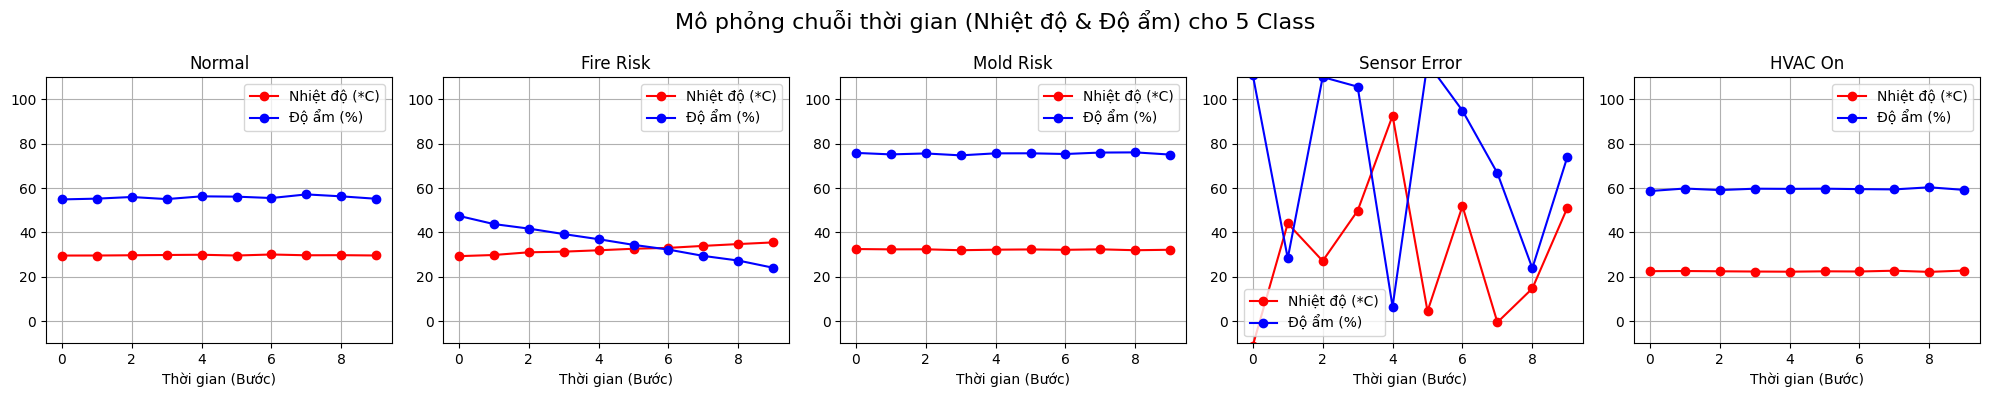

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== HYPERPARAMETERS =====
WINDOW_SIZE = 10         # Cửa sổ thời gian (10 điểm, tương đương 50s nếu sample rate = 5s)
NUM_FEATURES = 2         # 2 đặc trưng: Nhiệt độ, Độ ẩm
SAMPLES_PER_CLASS = 2000 # Số lượng mẫu cho mỗi class (Tổng: 10,000 mẫu)
NUM_CLASSES = 5

np.random.seed(42)
tf.random.set_seed(42)

# ===== DATA GENERATOR =====
def generate_timeseries_data(samples, window):
    steps = np.arange(window)

    # ==========================================
    # Class 0: NORMAL (Bình thường tại Việt Nam)
    # Nhiệt độ quanh 26-36°C, Ẩm 55-75%.
    # Trong 50 giây, giá trị dao động nhẹ, có nhiễu nhẹ của cảm biến.
    # ==========================================
    T_base_norm = np.random.uniform(26, 36, (samples, 1))
    T_norm = T_base_norm + np.random.normal(0, 0.2, (samples, window)) # Nhiễu ±0.2 độ

    H_base_norm = np.random.uniform(55, 75, (samples, 1))
    H_norm = H_base_norm + np.random.normal(0, 0.5, (samples, window)) # Nhiễu ±0.5 %

    X_0 = np.dstack((T_norm, H_norm))
    y_0 = np.full(samples, 0)

    # ==========================================
    # Class 1: FIRE_RISK (Nguy cơ cháy)
    # Bắt đầu từ nhiệt độ bình thường/nóng (28-36°C).
    # Nhiệt độ tăng liên tục, độ ẩm giảm.
    # ==========================================
    T_base_fire = np.random.uniform(28, 36, (samples, 1))
    T_slope_fire = np.random.uniform(0.5, 1.5, (samples, 1)) # Tăng 0.5 - 1.5 độ mỗi 5s
    T_fire = T_base_fire + T_slope_fire * steps + np.random.normal(0, 0.2, (samples, window))

    H_base_fire = np.random.uniform(40, 60, (samples, 1))
    H_slope_fire = np.random.uniform(1.0, 3.0, (samples, 1)) # Độ ẩm tụt nhanh 1-3% mỗi 5s
    H_fire = H_base_fire - H_slope_fire * steps + np.random.normal(0, 0.5, (samples, window))

    X_1 = np.dstack((T_fire, H_fire))
    y_1 = np.full(samples, 1)

    # ==========================================
    # Class 2: MOLD_RISK (Nguy cơ ẩm mốc)
    # Nhiệt độ mát/ấm (20-36°C), nhưng độ ẩm không khí ở mức cực cao (>75-95%).
    # ==========================================
    T_base_mold = np.random.uniform(20, 36, (samples, 1))
    T_mold = T_base_mold + np.random.normal(0, 0.2, (samples, window))

    H_base_mold = np.random.uniform(75, 95, (samples, 1))
    H_mold = H_base_mold + np.random.normal(0, 0.5, (samples, window))

    X_2 = np.dstack((T_mold, H_mold))
    y_2 = np.full(samples, 2)

    # ==========================================
    # Class 3: SENSOR_ERROR (Lỗi DHT20)
    # Cảm biến hỏng hoặc cáp lỏng: Dữ liệu nhảy vọt phi vật lý (vd: -10 độ, 150 độ)
    # hoặc dao động loạn xạ trong vòng 50s.
    # ==========================================
    T_err = np.random.uniform(-20, 100, (samples, window))
    H_err = np.random.uniform(0, 120, (samples, window))
    X_3 = np.dstack((T_err, H_err))
    y_3 = np.full(samples, 3)

    # ==========================================
    # Class 4: HVAC_ON (Đang bật Điều hòa)
    # Nhiệt độ mát mẻ (18-26°C), độ ẩm thấp (45-60%).
    # Trạng thái dao động nhẹ.
    # ==========================================
    T_base_hvac = np.random.uniform(18, 26, (samples, 1))
    T_hvac = T_base_hvac + np.random.normal(0, 0.2, (samples, window)) # Nhiễu ±0.2 độ

    H_base_hvac = np.random.uniform(45, 60, (samples, 1))
    H_hvac = H_base_hvac + np.random.normal(0, 0.5, (samples, window)) # Nhiễu ±0.5%

    X_4 = np.dstack((T_hvac, H_hvac))
    y_4 = np.full(samples, 4)

    X = np.concatenate((X_0, X_1, X_2, X_3, X_4), axis=0)
    y = np.concatenate((y_0, y_1, y_2, y_3, y_4), axis=0)

    return X, y

print("Đang sinh dữ liệu...")
X_data, y_labels = generate_timeseries_data(SAMPLES_PER_CLASS, WINDOW_SIZE)
print(f"Kích thước X: {X_data.shape} | Kích thước y: {y_labels.shape}")

# ===== DATA VISUALIZATION =====
class_names = ['Normal', 'Fire Risk', 'Mold Risk', 'Sensor Error', 'HVAC On']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Mô phỏng chuỗi thời gian (Nhiệt độ & Độ ẩm) cho 5 Class', fontsize=16)

for i in range(NUM_CLASSES):
    # Lấy mẫu đầu tiên của mỗi class
    sample_idx = i * SAMPLES_PER_CLASS
    temp_series = X_data[sample_idx, :, 0]
    humi_series = X_data[sample_idx, :, 1]

    ax = axes[i]
    ax.plot(temp_series, 'r-o', label='Nhiệt độ (*C)')
    ax.plot(humi_series, 'b-o', label='Độ ẩm (%)')
    ax.set_title(class_names[i])
    ax.set_xlabel('Thời gian (Bước)')
    ax.set_ylim(-10, 110)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ===== MODEL TRAINING =====
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

y_categorical = tf.keras.utils.to_categorical(y_labels, NUM_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_categorical, test_size=0.2, random_state=42, stratify=y_labels)

# Model Conv1D
model = Sequential([
    Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, NUM_FEATURES)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
])


optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Training
print("Bắt đầu huấn luyện...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Độ chính xác trên tập Test: {accuracy*100:.2f}%")

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1) # Lấy class có xác suất cao nhất
y_true = np.argmax(y_test, axis=1)
# In báo cáo chi tiết
class_names = ['0: Bình thường', '1: Quá nhiệt', '2: Ẩm/Nấm mốc', '3: Lỗi cảm biến', '4: Bật điều hòa']
print(classification_report(y_true, y_pred, target_names=class_names))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 8, 16)          │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,237 (4.83 KB)

 Trainable params: 1,237 (4.83 KB)

 Non-trainable params: 0 (0.00 B)

Bắt đầu huấn luyện...
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5920 - loss: 1.0395 - val_accuracy: 0.7800 - val_loss: 0.5207
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7064 - loss: 0.6148 - val_accuracy: 0.7950 - val_loss: 0.4443
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7510 - loss: 0.5553 - val_accuracy: 0.8190 - val_loss: 0.4273
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7734 - loss: 0.5228 - val_accuracy: 0.8155 - val_loss: 0.4166
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7825 - loss: 0.5034 - val_accuracy: 0.8290 - val_loss: 0.4038
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7851 - loss: 0.4922 - val_accuracy: 0.8355 - val_loss: 0.3901
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7887 - loss: 0.4776 - val_accuracy: 0.8390 - val_loss: 0.3872
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7906 - loss: 0.4

In [8]:
# ===== CONVERT TO TENSORFLOW LITE (TFLITE) =====
PREFIX = 'dht_anomaly_model_2'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = PREFIX + '.tflite'
output_header_path = PREFIX + '.h'

# Lưu file .tflite dạng nhị phân
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

with open(tflite_path, 'rb') as tflite_file:
    tflite_content = tflite_file.read()

# Chuyển các byte thành định dạng hex (0x..)
hex_lines = [', '.join([f'0x{byte:02x}' for byte in tflite_content[i:i + 12]])
             for i in range(0, len(tflite_content), 12)]

hex_array = ',\n  '.join(hex_lines)

# Ghi vào file Header (.h)
with open(output_header_path, 'w') as header_file:
    header_file.write(f'const unsigned char {PREFIX}_tflite[] = {{\n  ')
    header_file.write(f'{hex_array}\n')
    header_file.write('};\n\n')

print(f"Đã xuất model thành công ra file: {output_header_path}")
print(f"Kích thước model: {len(tflite_content)} bytes")

Saved artifact at '/tmp/tmpozhlmu0z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 2), dtype=tf.float32, name='keras_tensor_28')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132879462018384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132879462018960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132879462019920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132879462019152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132879462020304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132879462020112: TensorSpec(shape=(), dtype=tf.resource, name=None)
Đã xuất model thành công ra file: dht_anomaly_model_2.h
Kích thước model: 9532 bytes
